In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor

# Cargar los datos correctamente
from google.colab import files
uploaded = files.upload()

# Intenta detectar delimitador automáticamente
try:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';', low_memory=False)

# Eliminar columna de índice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Vista previa del DataFrame
df.head()

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022.csv


,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,TimeAlive,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,de_inferno,Terrorist,1,4,1,False,True,False,False,51.120.248.995.704.500,...,0,0,0,0,750,4400,0,0,0,0
1,de_inferno,Terrorist,1,4,1,False,True,False,False,4.348.662.552.266.170,...,0,0,0,0,800,4400,0,0,0,0
2,de_inferno,Terrorist,1,4,1,False,True,False,False,3.735.469.847.054.540,...,0,0,0,0,1000,4400,0,0,0,0
3,de_inferno,Terrorist,1,4,1,False,True,False,False,4.767.886.136.441.470,...,0,0,0,0,850,4400,0,0,0,0
4,de_inferno,Terrorist,1,4,1,False,True,True,False,5.312.251.089.027.310,...,0,0,0,0,1000,4400,0,0,0,0


In [2]:
# Nombres correctos de las columnas
column_names = [
    'PlayerId', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner',
    'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance',
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle',
    'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots'
]



# Columnas a convertir
cols_to_numeric = [
    'TimeAlive', 'TravelledDistance', 'RoundAssists', 'RoundHeadshots',
    'RoundStartingEquipmentValue', 'RoundKills', 'MatchKills', 'TeamStartingEquipmentValue'
]

# Convertir columnas a numéricas
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

# Eliminar filas con nulos en variables clave
df = df.dropna(subset=['MatchKills', 'TeamStartingEquipmentValue'])

# Convertir 'Survived' a booleano si existe
if 'Survived' in df.columns:
    df['Survived'] = df['Survived'].astype(bool)


# Resumen estadístico
cols_to_describe = [col for col in cols_to_numeric if col in df.columns]
print("\nResumen estadístico:")
print(df[cols_to_describe].describe())



Resumen estadístico:
        TimeAlive  TravelledDistance  RoundAssists  RoundHeadshots  \
count  780.000000         281.000000  79157.000000    79157.000000   
mean   281.343109        1184.341988      0.146178        0.301553   
std    292.553701       12337.137578      0.385601        0.578843   
min      0.000000           0.000000      0.000000        0.000000   
25%     54.125000           0.000000      0.000000        0.000000   
50%    105.125000           0.000000      0.000000        0.000000   
75%    531.875000           0.000000      0.000000        0.000000   
max    990.625000      171008.000000      4.000000        5.000000   

       RoundStartingEquipmentValue    RoundKills    MatchKills  \
count                 79157.000000  79157.000000  79157.000000   
mean                   3778.108695      0.671349      8.511578   
std                    2111.285406      0.881798      6.195079   
min                       0.000000      0.000000      0.000000   
25%              

Datos de entrenamiento: (55409, 5)
Datos de prueba: (23748, 5)
Raíz del Error Cuadrático Medio (RMSE): 1068.67
Coeficiente de Determinación (R²): 0.75


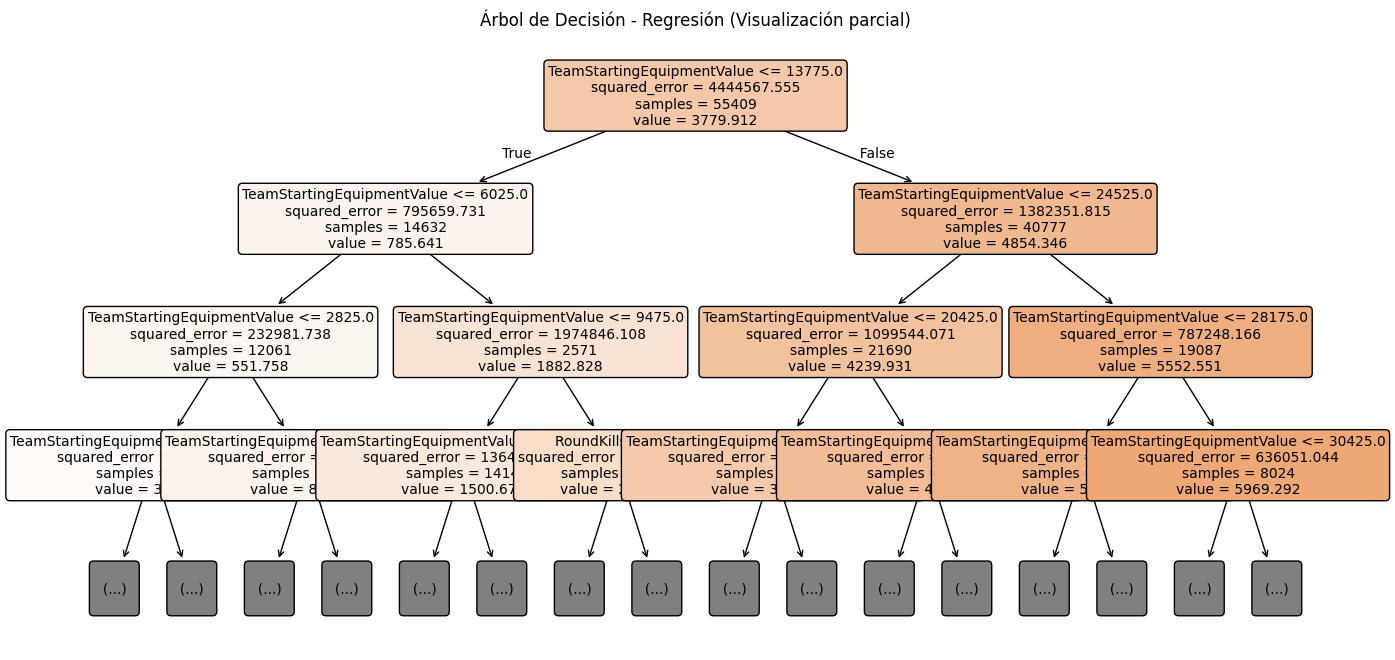

Mejor puntaje R² en CV: 0.8499
Mejores hiperparámetros: {'max_depth': 5, 'min_samples_split': 2}


,8
mean_fit_time,0.107226
std_fit_time,0.034046
mean_score_time,0.007765
std_score_time,0.003984
param_max_depth,5
param_min_samples_split,2
params,"{'max_depth': 5, 'min_samples_split': 2}"
split0_test_score,0.848736
split1_test_score,0.846899
split2_test_score,0.855213


Evaluación del árbol optimizado en test - RMSE: 822.88, R²: 0.85


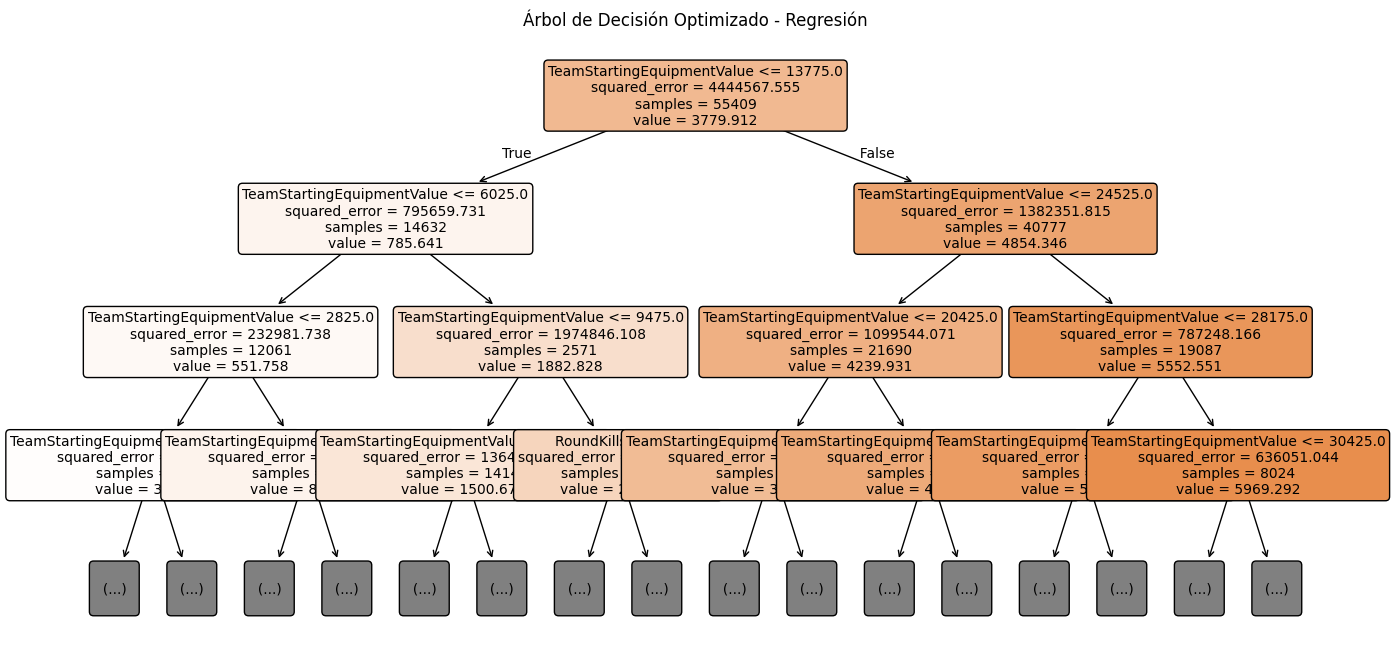

In [3]:
# Variables objetivo y predictoras
target = df['RoundStartingEquipmentValue']
features = df[['TeamStartingEquipmentValue', 'RoundId', 'TimeAlive', 'RoundKills', 'TravelledDistance']]

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, target, train_size=0.7, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba: {X_test.shape}")

# --- Entrenamiento de modelo base ---

arbol_regresion = DecisionTreeRegressor(random_state=42)
arbol_regresion.fit(X_train, y_train)

# --- Predicción y evaluación ---

predicciones = arbol_regresion.predict(X_test)

mse_val = mean_squared_error(y_test, predicciones)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test, predicciones)

print(f'Raíz del Error Cuadrático Medio (RMSE): {rmse_val:.2f}')
print(f'Coeficiente de Determinación (R²): {r2_val:.2f}')

# --- Visualización del árbol base  ---

plt.figure(figsize=(16,8))
plot_tree(
    arbol_regresion,
    feature_names=features.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title('Árbol de Decisión - Regresión (Visualización parcial)')
plt.show()

# --- Ajuste fino con validación cruzada ---

parametros = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [2, 3, 4, 5]
}

modelo = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(modelo, param_grid=parametros, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Mejor puntaje R² en CV: {grid_search.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")

# Resultados completos de la búsqueda
resultados_df = pd.DataFrame(grid_search.cv_results_)
display(resultados_df.iloc[grid_search.best_index_])

# --- Evaluación del mejor modelo en datos de prueba ---

mejor_arbol = grid_search.best_estimator_

y_pred_mejor = mejor_arbol.predict(X_test)

mse_mejor = mean_squared_error(y_test, y_pred_mejor)
rmse_mejor = np.sqrt(mse_mejor)
r2_mejor = r2_score(y_test, y_pred_mejor)

print(f"Evaluación del árbol optimizado en test - RMSE: {rmse_mejor:.2f}, R²: {r2_mejor:.2f}")

# --- Visualización del árbol optimizado

plt.figure(figsize=(16,8))
plot_tree(
    mejor_arbol,
    feature_names=features.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title('Árbol de Decisión Optimizado - Regresión')
plt.show()